In [1]:
from chipanalysis.utils.file_reader import *
from chipanalysis.utils.maye_video_axio  import *

from pathlib import Path
from aicspylibczi import CziFile
import matplotlib.pyplot as plt
import numpy as np
from chipanalysis.utils.ROI_selector import ROI_selector, ROI_selector_down
from chipanalysis.chip_alignment import align_chip_to_image,get_roi_from_result, ChipGeometry

from PIL import Image
import pandas as pd
import numpy as np
%load_ext autoreload
%autoreload 2

%matplotlib widget

In [20]:
root_path = "/Users/bisot/Documents/PostDoc2/test_data"
root_path = "/Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac"
root_path = "/Volumes/vangestel/Coco/ZeissData/pillartraining/"


fig_path = "/Users/bisot/Documents/PostDoc2/test_data"

czi_name = "CB7-04_S2.czi"
czi_name = "CB17-20.czi"

czi_path = Path(root_path,czi_name)
czi = CziFile(czi_path)

dims = czi.dims
sizes = czi.size

dim_sizes = dict(zip(dims, sizes))
dim_sizes["T"]
pixel_size = get_pixel_sizes_um(czi)
times = get_timestamps_by_T(czi, C=0, Z=0)


.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value


In [21]:
channel = 1
time = 0
img, img_disp = get_frame(czi,time,channel)

In [22]:
result = align_chip_to_image(img, pixel_size_um=pixel_size["X"], debug=False, geom=ChipGeometry())

In [23]:
def select_roi(img):
#     roi, _ = get_roi_from_result(
#     result,
#     result['rotate_fn'](img) ,
#     region= "bottom",
#     pad_left_um=-2600.0,   # expand chip box leftward (µm)
#     pad_right_um=-500.0,  # expand chip box rightward (µm)
#     pad_top_um=-500.0,    # pad above & below main channel centre (symmetric)
#     pad_bottom_um= 1300
# )
    return img[:,:]

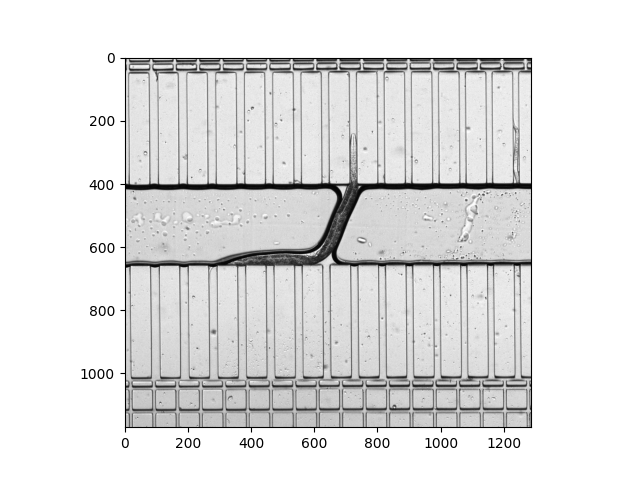

In [29]:

stretch_min = 0
stretch_max = 99.5
channel = 1
time = 2
img, img_disp = get_frame(czi,time,channel,gamma=1,stretch_min=stretch_min,stretch_max=stretch_max)
fig,ax = plt.subplots()
ax.imshow(select_roi(img_disp),cmap="gray")

In [30]:
import napari
import numpy as np

# ── Open image in napari for interactive polygon annotation ───────────────────
# Controls:
#   • Zoom/pan     : scroll wheel, drag with middle mouse / hold Space + drag
#   • Add polygon  : select "Shapes" layer → click Polygon tool in toolbar
#                    Left-click to add vertices, double-click to close
#   • New polygon  : after closing one, just start clicking again (adds to same layer)
#   • Delete shape : select shape, press Delete
#   • Move/edit    : switch to "Select" mode in toolbar

viewer = napari.Viewer(title="Draw channel masks — add as many polygons as needed")

# Add the grayscale image
viewer.add_image(img_disp, name="image", colormap="gray")

# Add an empty Shapes layer — user will draw polygons here
shapes_layer = viewer.add_shapes(
    name="channel_masks",
    shape_type="polygon",
    edge_color="cyan",
    face_color=[0, 1, 1, 0.2],   # semi-transparent cyan fill
    edge_width=3,
)

print("napari opened.")
print("  1. Select the 'channel_masks' layer in the layer list (bottom-left)")
print("  2. Click the polygon tool (pentagon icon) in the top toolbar")
print("  3. Click vertices on the image; double-click to close each polygon")
print("  4. Zoom: scroll wheel.  Pan: hold Space + drag")
print("  5. Draw as many polygons as needed")
print("  6. When done, run the next cell to extract the masks")
napari.run()


napari opened.
  1. Select the 'channel_masks' layer in the layer list (bottom-left)
  2. Click the polygon tool (pentagon icon) in the top toolbar
  3. Click vertices on the image; double-click to close each polygon
  4. Zoom: scroll wheel.  Pan: hold Space + drag
  5. Draw as many polygons as needed
  6. When done, run the next cell to extract the masks


In [2]:
import os
import tifffile
from matplotlib.path import Path as MplPath

# ── Extract polygon masks from napari shapes layer ────────────────────────────
H, W = img_disp.shape

all_polygons = shapes_layer.data
all_types    = shapes_layer.shape_type

manual_masks  = []
combined_mask = np.zeros((H, W), dtype=bool)

for i, (verts, stype) in enumerate(zip(all_polygons, all_types)):
    if stype != "polygon" or len(verts) < 3:
        continue
    # napari returns (row, col) → convert to (x, y) = (col, row) for MplPath
    verts_xy  = verts[:, [1, 0]]
    poly_path = MplPath(verts_xy)
    yy, xx    = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
    points    = np.column_stack([xx.ravel(), yy.ravel()])
    inside    = poly_path.contains_points(points).reshape(H, W)
    manual_masks.append(inside)
    combined_mask |= inside
    print(f"  Polygon {i+1}: {len(verts)} verts  {inside.sum():,} px  ({inside.mean()*100:.2f}%)")

print(f"\nTotal polygons : {len(manual_masks)}")
print(f"Combined mask  : {combined_mask.sum():,} px  ({combined_mask.mean()*100:.2f}%)")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img_disp, cmap="gray")
for verts in shapes_layer.data:
    closed = np.vstack([verts, verts[0]])
    axes[0].plot(closed[:, 1], closed[:, 0], 'c-', linewidth=2)
axes[0].set_title(f"Annotated polygons ({len(manual_masks)})", fontsize=10)
axes[0].axis("off")
axes[1].imshow(combined_mask, cmap="gray")
axes[1].set_title(f"Combined mask ({combined_mask.mean()*100:.2f}%)", fontsize=10)
axes[1].axis("off")
plt.tight_layout()
plt.show()

# ── Update binary mask for downstream analysis ────────────────────────────────
binary = combined_mask
print("\n'binary' updated — re-run the normalization and worm-detection cells if needed.")

NameError: name 'img_disp' is not defined

In [10]:

from skimage import exposure as _exp

# ── Parameters ────────────────────────────────────────────────────────────────
WORM_DATA_DIR     = "/Users/bisot/Documents/PostDoc2/training_data_worms"
PATCH_SIZE_PX     = 256
PATCH_STRIDE_PX   = 128
MIN_MASK_FRACTION = 0.0    # discard patches with less than this mask fraction
SKIP_IF_EXISTS    = True

os.makedirs(os.path.join(WORM_DATA_DIR, "images"), exist_ok=True)
os.makedirs(os.path.join(WORM_DATA_DIR, "masks"),  exist_ok=True)

# ── Tile image + mask into patches and save to training dataset ───────────────
img_norm_save = _exp.rescale_intensity(img_disp.astype(float), out_range=(0.0, 1.0)).astype(np.float32)
mask_save     = combined_mask.astype(np.uint8)

source_tag = f"{czi_path.stem}_worm_ch{channel}_t{time}"
saved, skipped = 0, 0

for r in range(0, H - PATCH_SIZE_PX + 1, PATCH_STRIDE_PX):
    for c in range(0, W - PATCH_SIZE_PX + 1, PATCH_STRIDE_PX):
        img_patch  = img_norm_save[r:r+PATCH_SIZE_PX, c:c+PATCH_SIZE_PX]
        mask_patch = mask_save    [r:r+PATCH_SIZE_PX, c:c+PATCH_SIZE_PX]
        if mask_patch.mean() < MIN_MASK_FRACTION:
            continue
        name     = f"{source_tag}_r{r:05d}_c{c:05d}"
        img_out  = os.path.join(WORM_DATA_DIR, "images", f"{name}.tif")
        mask_out = os.path.join(WORM_DATA_DIR, "masks",  f"{name}.tif")
        if SKIP_IF_EXISTS and os.path.exists(img_out):
            skipped += 1
            continue
        tifffile.imwrite(img_out,  img_patch)
        tifffile.imwrite(mask_out, mask_patch)
        saved += 1

total = len([f for f in os.listdir(os.path.join(WORM_DATA_DIR, "images")) if f.endswith(".tif")])
print(f"Source tag    : {source_tag}")
print(f"Saved         : {saved}   Skipped (exist): {skipped}")
print(f"Dataset total : {total} patches  →  {WORM_DATA_DIR}")


NameError: name 'img_disp' is not defined

C. elegans dataset : 522 image patches  |  522 mask patches
Directory          : /Users/bisot/Documents/PostDoc2/training_data_worms
Worm coverage / patch : mean=1.0%  min=0.0%  max=18.8%


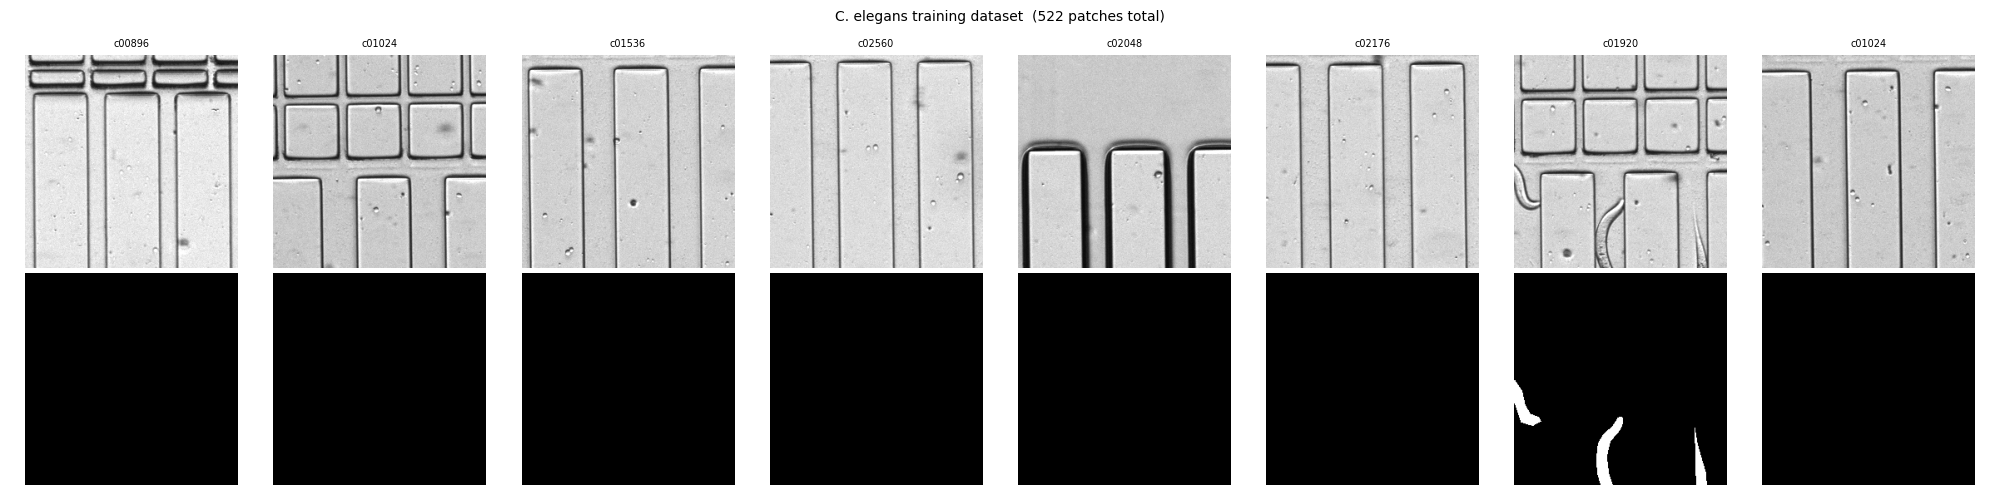

In [11]:

import glob, random as _random

# ── Load & inspect the C. elegans training dataset ────────────────────────────
_img_dir  = os.path.join(WORM_DATA_DIR, "images")
_mask_dir = os.path.join(WORM_DATA_DIR, "masks")

img_paths  = sorted(glob.glob(os.path.join(_img_dir,  "*.tif")))
mask_paths = sorted(glob.glob(os.path.join(_mask_dir, "*.tif")))

print(f"C. elegans dataset : {len(img_paths)} image patches  |  {len(mask_paths)} mask patches")
print(f"Directory          : {WORM_DATA_DIR}")

if img_paths:
    # ── Summary stats ─────────────────────────────────────────────────────────
    mask_fractions = []
    for mp in mask_paths:
        m = tifffile.imread(mp)
        mask_fractions.append(m.mean())
    mask_fractions = np.array(mask_fractions)
    print(f"Worm coverage / patch : mean={mask_fractions.mean()*100:.1f}%  "
          f"min={mask_fractions.min()*100:.1f}%  max={mask_fractions.max()*100:.1f}%")

    # ── Show a random sample ──────────────────────────────────────────────────
    N_SHOW = min(8, len(img_paths))
    sample_names = [os.path.basename(p) for p in _random.sample(img_paths, N_SHOW)]

    fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 2.5, 5))
    if N_SHOW == 1:
        axes = axes[:, np.newaxis]
    for j, fname in enumerate(sample_names):
        ip = tifffile.imread(os.path.join(_img_dir,  fname))
        mp = tifffile.imread(os.path.join(_mask_dir, fname))
        axes[0, j].imshow(ip, cmap="gray", vmin=0, vmax=1)
        axes[0, j].set_title(fname.rsplit("_", 2)[-1].replace(".tif", ""), fontsize=7)
        axes[0, j].axis("off")
        axes[1, j].imshow(mp, cmap="gray", vmin=0, vmax=1)
        axes[1, j].axis("off")
    axes[0, 0].set_ylabel("Image", fontsize=9)
    axes[1, 0].set_ylabel("Worm mask",  fontsize=9)
    plt.suptitle(f"C. elegans training dataset  ({len(img_paths)} patches total)", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("Dataset is empty — run the save cell first.")


## Create C. elegans Training Data

Saves **single-channel brightfield** patches + binary worm masks to a dedicated dataset.  
Re-running is idempotent (existing patches are skipped); changing the CZI file or ROI appends new patches.


In [13]:

# ── Optional: include an extra dataset for training ───────────────────────────
# Set INCLUDE_EXTRA_DATASET = True to combine a second patch directory (e.g.
# from a different experiment or organism) with the C. elegans patches.
# Background patches in the extra set are balanced to avoid overwhelming the
# signal patches.

INCLUDE_EXTRA_DATASET    = False   # ← flip to True to merge a second dataset
EXTRA_DATA_DIR           = "/Users/bisot/Documents/PostDoc2/training_data_extra"
EXTRA_BALANCE_BACKGROUND = True    # keep at most as many empty patches as signal patches
EXTRA_MIN_MASK_FRACTION  = 0.01   # patches below this mask fraction are "background"

_extra_img_dir = os.path.join(EXTRA_DATA_DIR, "images")

if INCLUDE_EXTRA_DATASET and os.path.isdir(_extra_img_dir):
    _n_extra_total = len([f for f in os.listdir(_extra_img_dir) if f.endswith(".tif")])
    print(f"Extra dataset : {_n_extra_total} patches on disk  ({EXTRA_DATA_DIR})")
    print(f"  Balance background : {EXTRA_BALANCE_BACKGROUND}  "
          f"(min mask fraction = {EXTRA_MIN_MASK_FRACTION})")
    print("  → will be merged with C. elegans dataset at training time")
elif INCLUDE_EXTRA_DATASET:
    print(f"⚠️  Extra dataset not found at {EXTRA_DATA_DIR!r}  — training on worm data only")
    INCLUDE_EXTRA_DATASET = False
else:
    print("Extra dataset disabled — training on C. elegans worm data only")


Extra dataset disabled — training on C. elegans worm data only


## U-Net Training — C. elegans Segmentation

Single-channel brightfield U-Net for binary worm segmentation.

| Detail | Value |
|--------|-------|
| **Input** | `(1, H, W)` single-channel brightfield patch |
| **Output** | `(1, H, W)` sigmoid probability map |
| **Loss** | 0.5 × BCE + 0.5 × Dice |
| **Augmentation** | flips, 90° rotations, brightness / contrast jitter, Gaussian noise |
| **Downscaling** | optional `DOWNSCALE_FACTOR` — set to 2 to halve patch resolution |
| **Background balancing** | `balance_background=True` in `WormDataset` keeps negatives ≤ signal count |

With only a handful of training patches, aggressive augmentation is critical.  
Run the *model definition* cell once, then the *training* cell (it resumes from checkpoint).


In [14]:

import os
import tifffile
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from skimage.transform import resize, rotate

# ─────────────────────────────────────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────────────────────────────────────
DOWNSCALE_FACTOR = 1        # 1 = no downscaling; 2 = patches become 128×128

# ─────────────────────────────────────────────────────────────────────────────
# Building block
# ─────────────────────────────────────────────────────────────────────────────
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

# ─────────────────────────────────────────────────────────────────────────────
# U-Net  — 4-level encoder/decoder for C. elegans segmentation
# ─────────────────────────────────────────────────────────────────────────────
class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1,
                 features=(32, 64, 128, 256)):
        super().__init__()
        self.pool = nn.MaxPool2d(2, 2)
        self.downs     = nn.ModuleList()
        self.ups_trans = nn.ModuleList()
        self.ups_conv  = nn.ModuleList()

        ch = in_channels
        for feat in features:
            self.downs.append(DoubleConv(ch, feat))
            ch = feat

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        for feat in reversed(features):
            self.ups_trans.append(nn.ConvTranspose2d(feat * 2, feat, 2, stride=2))
            self.ups_conv.append(DoubleConv(feat * 2, feat))

        self.final = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        for i, (up_t, up_c) in enumerate(zip(self.ups_trans, self.ups_conv)):
            x = up_t(x)
            s = skips[-(i + 1)]
            if x.shape != s.shape:
                x = F.interpolate(x, size=s.shape[2:])
            x = torch.cat([s, x], dim=1)
            x = up_c(x)
        return self.final(x)

# ─────────────────────────────────────────────────────────────────────────────
# Dataset with rich augmentation and optional background balancing
# ─────────────────────────────────────────────────────────────────────────────
class WormDataset(Dataset):
    """
    Single-channel (H,W) brightfield images + binary worm masks.

    Augmentations applied jointly to image & mask:
      • random horizontal / vertical flip
      • random 90° rotation (k ∈ {0,1,2,3})
      • random arbitrary rotation ±45°
      • brightness shift  (additive, image only)
      • contrast scale     (multiplicative, image only)
      • Gaussian noise     (image only)

    Optional spatial downscaling by `downscale`.

    Parameters
    ----------
    balance_background : bool
        If True, keep at most as many empty-mask patches as signal patches,
        chosen randomly (seed=42).  Prevents background-heavy datasets from
        dominating training.
    min_mask_fraction : float
        Patches whose mask mean is below this value are considered background.
        Default 0.0 — only fully-empty masks count as background.
    """
    def __init__(self, images_dir, masks_dir, augment=True, downscale=1,
                 balance_background=False, min_mask_fraction=0.0):
        self.images_dir = images_dir
        self.masks_dir  = masks_dir
        self.augment    = augment
        self.downscale  = downscale

        all_names = sorted(f for f in os.listdir(images_dir) if f.endswith(".tif"))

        if balance_background:
            signal_names, bg_names = [], []
            for fname in all_names:
                m = tifffile.imread(os.path.join(masks_dir, fname))
                if m.mean() > min_mask_fraction:
                    signal_names.append(fname)
                else:
                    bg_names.append(fname)
            # Keep at most len(signal) background patches
            rng = random.Random(42)
            n_bg_keep = min(len(bg_names), max(len(signal_names), 1))
            bg_kept   = rng.sample(bg_names, n_bg_keep)
            self.names = sorted(signal_names + bg_kept)
            print(f"  [balance] {len(signal_names)} signal  +  {n_bg_keep}/{len(bg_names)} bg kept"
                  f"  →  {len(self.names)} patches total")
        else:
            self.names = all_names

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        fname    = self.names[idx]
        img_arr  = tifffile.imread(os.path.join(self.images_dir, fname)).astype(np.float32)
        mask_arr = tifffile.imread(os.path.join(self.masks_dir,  fname)).astype(np.float32)

        # Optional downscale
        if self.downscale > 1:
            h, w = img_arr.shape
            new_h, new_w = h // self.downscale, w // self.downscale
            img_arr  = resize(img_arr,  (new_h, new_w), preserve_range=True, anti_aliasing=True).astype(np.float32)
            mask_arr = resize(mask_arr, (new_h, new_w), preserve_range=True, order=0).astype(np.float32)
            mask_arr = (mask_arr > 0.5).astype(np.float32)

        img_t  = torch.from_numpy(img_arr).unsqueeze(0)   # (1, H, W)
        mask_t = torch.from_numpy(mask_arr).unsqueeze(0)  # (1, H, W)

        if self.augment:
            # ── Spatial augmentation (applied to both) ───────────────────
            if torch.rand(1) > 0.5:
                img_t  = torch.flip(img_t,  [2])       # horizontal flip
                mask_t = torch.flip(mask_t, [2])
            if torch.rand(1) > 0.5:
                img_t  = torch.flip(img_t,  [1])       # vertical flip
                mask_t = torch.flip(mask_t, [1])
            k = int(torch.randint(0, 4, (1,)))
            img_t  = torch.rot90(img_t,  k, [1, 2])
            mask_t = torch.rot90(mask_t, k, [1, 2])
            # ── Random arbitrary rotation ±45° ───────────────────────────
            angle = (torch.rand(1) * 90 - 45).item()
            img_t  = torch.from_numpy(
                rotate(img_t.squeeze(0).numpy(), angle, order=1, preserve_range=True)
            ).float().unsqueeze(0)
            mask_t = torch.from_numpy(
                rotate(mask_t.squeeze(0).numpy(), angle, order=0, preserve_range=True)
            ).float().unsqueeze(0)

            # ── Photometric augmentation (image only) ────────────────────
            img_t = img_t + (torch.rand(1) * 0.2 - 0.1)       # brightness ∈ [-0.1, +0.1]
            img_t = img_t * (0.8 + torch.rand(1) * 0.4)        # contrast   ∈ [0.8, 1.2]
            sigma = torch.rand(1) * 0.03
            img_t = img_t + torch.randn_like(img_t) * sigma    # Gaussian noise
            img_t = img_t.clamp(0.0, 1.0)

        return img_t, mask_t

# ─────────────────────────────────────────────────────────────────────────────
# Sanity check
# ─────────────────────────────────────────────────────────────────────────────
_ds = WormDataset(
    os.path.join(WORM_DATA_DIR, "images"),
    os.path.join(WORM_DATA_DIR, "masks"),
    augment=False,
    downscale=DOWNSCALE_FACTOR,
    balance_background=True,
    min_mask_fraction=0.01,
)
_img0, _mask0 = _ds[0]
print(f"Dataset size     : {len(_ds)} patches")
print(f"Image shape      : {tuple(_img0.shape)}   (patch = {_img0.shape[1]}×{_img0.shape[2]} px)")
print(f"Mask  shape      : {tuple(_mask0.shape)}")
print(f"Downscale factor : {DOWNSCALE_FACTOR}×")

device = (
    torch.device("cuda") if torch.cuda.is_available()
    else torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Device           : {device}")

model = UNet(in_channels=1, out_channels=1, features=(32, 64, 128, 256)).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"U-Net parameters : {n_params:,}")


  [balance] 103 signal  +  103/419 bg kept  →  206 patches total
Dataset size     : 206 patches
Image shape      : (1, 256, 256)   (patch = 256×256 px)
Mask  shape      : (1, 256, 256)
Downscale factor : 1×
Device           : mps
U-Net parameters : 7,762,465


In [ ]:

import torch.optim as optim

# ── Hyperparameters ───────────────────────────────────────────────────────────
N_EPOCHS    = 150         # more epochs because dataset is typically small
BATCH_SIZE  = 4
LR          = 1e-4
VAL_SPLIT   = 0.2
MODEL_SAVE  = os.path.join(WORM_DATA_DIR, "unet_celegans_best.pth")

# ── Primary C. elegans dataset (with background balancing) ────────────────────
print("Building C. elegans dataset (balancing background patches)…")
_worm_ds = WormDataset(
    os.path.join(WORM_DATA_DIR, "images"),
    os.path.join(WORM_DATA_DIR, "masks"),
    augment=True,
    downscale=DOWNSCALE_FACTOR,
    balance_background=True,
    min_mask_fraction=0.01,
)

# ── Optional extra dataset ────────────────────────────────────────────────────
if INCLUDE_EXTRA_DATASET:
    print("Building extra dataset (balancing background patches)…")
    _extra_ds = WormDataset(
        os.path.join(EXTRA_DATA_DIR, "images"),
        os.path.join(EXTRA_DATA_DIR, "masks"),
        augment=True,
        downscale=DOWNSCALE_FACTOR,
        balance_background=EXTRA_BALANCE_BACKGROUND,
        min_mask_fraction=EXTRA_MIN_MASK_FRACTION,
    )
    full_ds = torch.utils.data.ConcatDataset([_worm_ds, _extra_ds])
    print(f"Combined dataset   : {len(_worm_ds)} worm  +  {len(_extra_ds)} extra  =  {len(full_ds)} patches")
else:
    full_ds = _worm_ds
    print(f"Worm-only dataset  : {len(full_ds)} patches")

n_val   = max(1, int(len(full_ds) * VAL_SPLIT))
n_train = len(full_ds) - n_val
train_ds, val_ds = torch.utils.data.random_split(
    full_ds, [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

def _set_augment(flag):
    _worm_ds.augment = flag
    if INCLUDE_EXTRA_DATASET:
        _extra_ds.augment = flag

_set_augment(False)   # start with augmentation off

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
print(f"Train : {n_train} patches   Val : {n_val} patches")

# ── Model, optimiser, scheduler ───────────────────────────────────────────────
model     = UNet(in_channels=1, out_channels=1, features=(32, 64, 128, 256)).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

start_epoch = 1
if os.path.exists(MODEL_SAVE):
    model.load_state_dict(torch.load(MODEL_SAVE, map_location=device, weights_only=True))
    print(f"Resumed from checkpoint: {MODEL_SAVE}")

# ── Loss: 0.5 BCE + 0.5 Dice ─────────────────────────────────────────────────
def dice_loss(logits, target, eps=1e-6):
    pred  = torch.sigmoid(logits)
    inter = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return 1 - (2 * inter + eps) / (union + eps)

def criterion(logits, target):
    bce  = F.binary_cross_entropy_with_logits(logits, target)
    dice = dice_loss(logits, target).mean()
    return 0.5 * bce + 0.5 * dice

# ── Training loop ─────────────────────────────────────────────────────────────
train_losses, val_losses = [], []
best_val = float("inf")

for epoch in range(start_epoch, N_EPOCHS + 1):
    # --- Train ---
    model.train()
    _set_augment(True)
    t_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), masks)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
    t_loss /= len(train_loader)

    # --- Validate ---
    model.eval()
    _set_augment(False)
    v_loss = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            v_loss += criterion(model(imgs), masks).item()
    v_loss /= len(val_loader)

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    scheduler.step(v_loss)

    if v_loss < best_val:
        best_val = v_loss
        torch.save(model.state_dict(), MODEL_SAVE)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{N_EPOCHS}  train={t_loss:.4f}  val={v_loss:.4f}  best={best_val:.4f}")

print(f"\nBest model saved → {MODEL_SAVE}")

# ── Loss curves ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label="train")
ax.plot(val_losses,   label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE + Dice loss")
ax.legend()
ax.set_title("U-Net C. elegans training")
plt.tight_layout()
plt.show()


Building C. elegans dataset (balancing background patches)…
  [balance] 103 signal  +  103/419 bg kept  →  206 patches total
Worm-only dataset  : 206 patches
Train : 165 patches   Val : 41 patches
Epoch   1/150  train=0.7828  val=0.7947  best=0.7947
Epoch  10/150  train=0.5998  val=0.5732  best=0.5732
Epoch  20/150  train=0.5235  val=0.5090  best=0.5042
Epoch  30/150  train=0.4681  val=0.4581  best=0.4496
Epoch  40/150  train=0.4131  val=0.4088  best=0.4088
Epoch  50/150  train=0.3752  val=0.3779  best=0.3754
Epoch  60/150  train=0.3573  val=0.3552  best=0.3552
Epoch  70/150  train=0.3409  val=0.3420  best=0.3394
Epoch  80/150  train=0.3142  val=0.3609  best=0.3318
Epoch  90/150  train=0.3165  val=0.3282  best=0.3276


In [ ]:

# ── Inference preview on validation patches ───────────────────────────────────
model.eval()
model.load_state_dict(torch.load(MODEL_SAVE, map_location=device, weights_only=True))

n_show = min(4, n_val)
val_imgs, val_masks = [], []
for i in range(n_show):
    img_t, mask_t = val_ds[i]
    val_imgs.append(img_t)
    val_masks.append(mask_t)

imgs_batch  = torch.stack(val_imgs).to(device)
masks_batch = torch.stack(val_masks)

with torch.no_grad():
    preds = torch.sigmoid(model(imgs_batch)).cpu().numpy()[:, 0]   # (N, H, W)

imgs_np  = imgs_batch.cpu().numpy()[:, 0]     # (N, H, W)  single channel
masks_np = masks_batch.numpy()[:, 0]           # (N, H, W)

fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 10))
if n_show == 1:
    axes = axes[:, np.newaxis]
for i in range(n_show):
    axes[0, i].imshow(imgs_np[i], cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title("Brightfield", fontsize=9)
    axes[0, i].axis("off")

    axes[1, i].imshow(masks_np[i], cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title("GT mask", fontsize=9)
    axes[1, i].axis("off")

    axes[2, i].imshow(preds[i], cmap="viridis", vmin=0, vmax=1)
    axes[2, i].set_title("Prediction", fontsize=9)
    axes[2, i].axis("off")

plt.suptitle("U-Net C. elegans inference — validation patches", fontsize=11)
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/Users/bisot/Documents/PostDoc2/training_data_worms/unet_cell_best.pth'

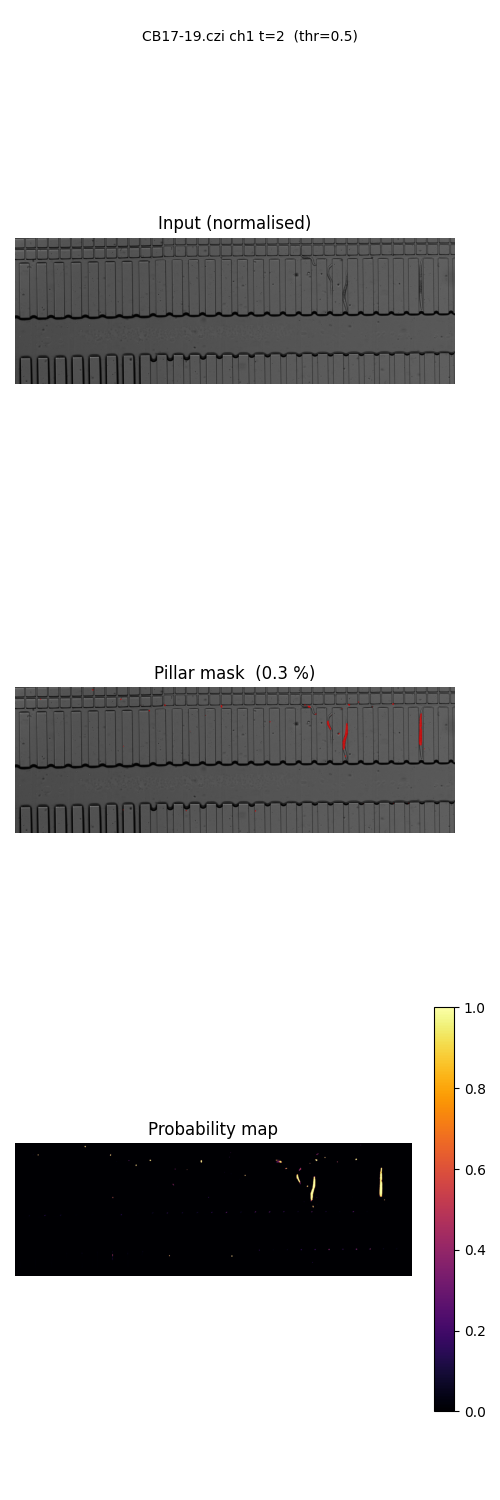

Pillar coverage: 0.30 %


In [ ]:

def predict_worms(
    image,
    model_path=None,
    threshold=0.5,
    patch_size=None,
    patch_stride=None,
    show_plot=True,
    title="C. elegans prediction",
):
    """
    Run C. elegans U-Net inference on any 2-D image (numpy array).

    The image is normalised to [0, 1] internally — pass any dtype / range.

    Parameters
    ----------
    image : np.ndarray, shape (H, W)
        Single-channel brightfield image (any dtype, any value range).
    model_path : str or Path, optional
        Checkpoint path.  Defaults to the notebook's MODEL_SAVE.
    threshold : float
        Probability cutoff for the binary mask.
    patch_size : int, optional
        Sliding-window patch side.  Defaults to PATCH_SIZE_PX from training.
    patch_stride : int, optional
        Sliding-window stride.  Defaults to PATCH_STRIDE_PX from training.
    show_plot : bool
        If True, display a comparison figure.
    title : str
        Figure super-title.

    Returns
    -------
    dict  with keys
        'prob_map'     – (H, W) float32 probability map
        'pred_binary'  – (H, W) bool binary mask
        'img_norm'     – (H, W) float32 normalised input
        'coverage'     – float ∈ [0, 1]
    """
    _model_path  = model_path or MODEL_SAVE
    _patch_sz    = patch_size  or PATCH_SIZE_PX
    _patch_str   = patch_stride or PATCH_STRIDE_PX

    # ── Normalise to [0, 1] float32 ─────────────────────────────────────────
    img_norm = image.astype(np.float64)
    vmin, vmax = img_norm.min(), img_norm.max()
    if vmax - vmin > 0:
        img_norm = (img_norm - vmin) / (vmax - vmin)
    img_norm = img_norm.astype(np.float32)

    H_img, W_img = img_norm.shape

    # ── Load model ───────────────────────────────────────────────────────────
    _model = UNet(in_channels=1, out_channels=1, features=(32, 64, 128, 256)).to(device)
    _model.load_state_dict(torch.load(_model_path, map_location=device, weights_only=True))
    _model.eval()

    # ── Sliding-window inference ─────────────────────────────────────────────
    prob_sum = np.zeros((H_img, W_img), dtype=np.float32)
    count    = np.zeros((H_img, W_img), dtype=np.float32)

    with torch.no_grad():
        for r in range(0, H_img - _patch_sz + 1, _patch_str):
            for c in range(0, W_img - _patch_sz + 1, _patch_str):
                patch = img_norm[r:r+_patch_sz, c:c+_patch_sz]
                t = torch.from_numpy(patch[np.newaxis, np.newaxis]).to(device)  # (1,1,P,P)
                prob = torch.sigmoid(_model(t)).squeeze().cpu().numpy()
                prob_sum[r:r+_patch_sz, c:c+_patch_sz] += prob
                count   [r:r+_patch_sz, c:c+_patch_sz] += 1.0

    count    = np.where(count == 0, 1, count)
    prob_map = prob_sum / count
    pred_bin = prob_map >= threshold
    coverage = pred_bin.mean()

    # ── Visualisation ────────────────────────────────────────────────────────
    if show_plot:
        fig, axes = plt.subplots(3, 1, figsize=(5, 15), sharex=True, sharey=True)

        axes[0].imshow(img_norm, cmap="gray", vmin=0, vmax=1)
        axes[0].set_title("Input (normalised)")

        ov = np.stack([img_norm]*3, axis=-1).copy()
        ov[pred_bin, 0] = np.clip(ov[pred_bin, 0] * 0.3 + 0.7, 0, 1)
        ov[pred_bin, 1] = np.clip(ov[pred_bin, 1] * 0.3,        0, 1)
        ov[pred_bin, 2] = np.clip(ov[pred_bin, 2] * 0.3,        0, 1)
        axes[1].imshow(np.clip(ov, 0, 1))
        axes[1].set_title(f"Worm mask  ({coverage*100:.1f} %)")

        im = axes[2].imshow(prob_map, cmap="inferno", vmin=0, vmax=1)
        plt.colorbar(im, ax=axes[2], fraction=0.046)
        axes[2].set_title("Probability map")

        for ax in axes:
            ax.axis("off")
        plt.suptitle(f"{title}  (thr={threshold})", fontsize=10)
        plt.tight_layout()
        plt.show()

    return {
        "prob_map":    prob_map,
        "pred_binary": pred_bin,
        "img_norm":    img_norm,
        "coverage":    coverage,
    }

def select_roi2(img):
#     roi, _ = get_roi_from_result(
#     result,
#     result['rotate_fn'](img) ,
#     region= "full",
#     pad_left_um=-1500.0,   # expand chip box leftward (µm)
#     pad_right_um=-3500.0,  # expand chip box rightward (µm)
#     pad_top_um=1300.0,    # pad above & below main channel centre (symmetric)
#     pad_bottom_um= 1300
# )
    return img

channel = 1
time = 2
img, _ = get_frame(czi, time, channel, gamma=0.45, stretch_min=stretch_min, stretch_max=stretch_max)
PATCH_SIZE_PX   = 256    # patch side length in pixels (square)
PATCH_STRIDE_PX = 128    # stride (50 % overlap)

# ── Quick test on the current brightfield frame ───────────────────────────────
res = predict_worms(select_roi2(img), threshold=0.5, title=f"{czi_path.name}  ch{channel}  t={time}")
print(f"Worm coverage: {res['coverage']*100:.2f} %")


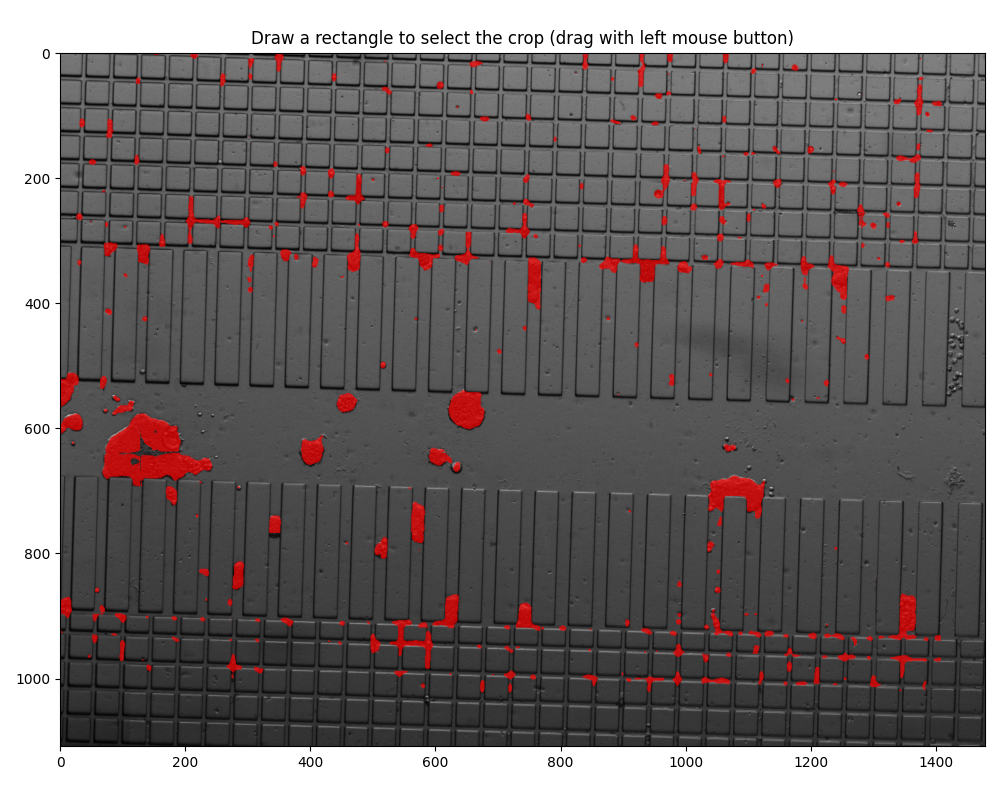

In [ ]:

# ── Interactive crop selection on the predicted image ─────────────────────────
# Draw a rectangle on the figure; the selected coordinates are stored in
# `crop_coords` as (row_start, row_end, col_start, col_end).
from matplotlib.widgets import RectangleSelector
import matplotlib.patches as mpatches

crop_coords = {}   # will be filled by the selector callback

_img_for_crop = res["img_norm"]

fig_crop, ax_crop = plt.subplots(figsize=(10, 8))
_ov = np.stack([_img_for_crop]*3, axis=-1).copy()
_bin = res["pred_binary"]
_ov[_bin, 0] = np.clip(_ov[_bin, 0] * 0.3 + 0.7, 0, 1)
_ov[_bin, 1] = np.clip(_ov[_bin, 1] * 0.3,        0, 1)
_ov[_bin, 2] = np.clip(_ov[_bin, 2] * 0.3,        0, 1)
ax_crop.imshow(np.clip(_ov, 0, 1))
ax_crop.set_title("Draw a rectangle to select the crop (drag with left mouse button)")

def _on_select(eclick, erelease):
    c0, r0 = int(eclick.xdata),   int(eclick.ydata)
    c1, r1 = int(erelease.xdata), int(erelease.ydata)
    r0, r1 = min(r0, r1), max(r0, r1)
    c0, c1 = min(c0, c1), max(c0, c1)
    crop_coords.update(dict(r0=r0, r1=r1, c0=c0, c1=c1))
    print(f"Selected crop  rows {r0}:{r1}  cols {c0}:{c1}  "
          f"({r1-r0} × {c1-c0} px)")

_rs = RectangleSelector(
    ax_crop, _on_select,
    useblit=True,
    button=[1],
    minspanx=10, minspany=10,
    spancoords="pixels",
    interactive=True,
)
plt.tight_layout()
plt.show()


Crop shape : (267, 406)
Saved 2 new patches from crop  →  dataset now has 250 patches total


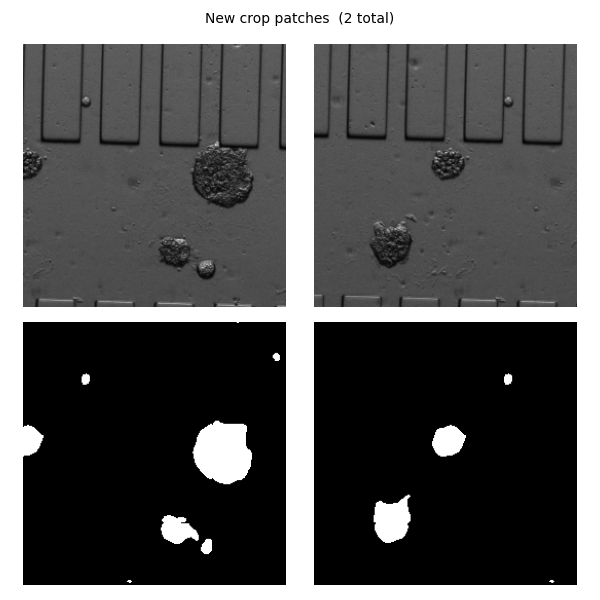

In [ ]:

# ── Save cropped image + predicted mask to training dataset ───────────────────
# Requires `crop_coords` to be filled by the cell above.

assert crop_coords, "No crop selected — run the cell above and draw a rectangle first."

r0, r1 = crop_coords["r0"], crop_coords["r1"]
c0, c1 = crop_coords["c0"], crop_coords["c1"]

crop_img  = res["img_norm"][r0:r1, c0:c1]                         # float32 normalised
crop_mask = res["pred_binary"][r0:r1, c0:c1].astype(np.uint8)     # binary uint8

print(f"Crop shape : {crop_img.shape}")

# ── Tile the crop into PATCH_SIZE_PX patches ──────────────────────────────────
source_tag_crop = f"{czi_path.stem}_crop_r{r0}c{c0}_ch{channel}_t{time}"
H_c, W_c = crop_img.shape

saved_crop = 0
for r in range(0, H_c - PATCH_SIZE_PX + 1, PATCH_STRIDE_PX):
    for c in range(0, W_c - PATCH_SIZE_PX + 1, PATCH_STRIDE_PX):
        img_patch  = crop_img [r:r+PATCH_SIZE_PX, c:c+PATCH_SIZE_PX].astype(np.float32)
        mask_patch = crop_mask[r:r+PATCH_SIZE_PX, c:c+PATCH_SIZE_PX]
        name       = f"{source_tag_crop}_r{r:05d}_c{c:05d}"

        img_out  = os.path.join(WORM_DATA_DIR, "images", f"{name}.tif")
        mask_out = os.path.join(WORM_DATA_DIR, "masks",  f"{name}.tif")

        if SKIP_IF_EXISTS and os.path.exists(img_out):
            continue
        tifffile.imwrite(img_out,  img_patch)
        tifffile.imwrite(mask_out, mask_patch)
        saved_crop += 1

total_now = len([f for f in os.listdir(os.path.join(WORM_DATA_DIR, "images")) if f.endswith(".tif")])
print(f"Saved {saved_crop} new patches from crop  →  dataset now has {total_now} patches total")

# ── Quick preview of a few saved crop patches ─────────────────────────────────
crop_names = sorted(f for f in os.listdir(os.path.join(WORM_DATA_DIR, "images"))
                    if f.startswith(source_tag_crop) and f.endswith(".tif"))
n_show = min(6, len(crop_names))
if n_show:
    sample = random.sample(crop_names, n_show)
    fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
    for i, fname in enumerate(sample):
        ip = tifffile.imread(os.path.join(WORM_DATA_DIR, "images", fname))
        mp = tifffile.imread(os.path.join(WORM_DATA_DIR, "masks",  fname))
        axes[0, i].imshow(ip, cmap="gray", vmin=0, vmax=1); axes[0, i].axis("off")
        axes[1, i].imshow(mp, cmap="gray", vmin=0, vmax=1); axes[1, i].axis("off")
    axes[0, 0].set_ylabel("Brightfield", fontsize=9)
    axes[1, 0].set_ylabel("Worm mask",   fontsize=9)
    plt.suptitle(f"New crop patches  ({len(crop_names)} total)", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("No new patches to preview (all already existed).")


## Whole-CZI Prediction — Visualise Over Time

Runs the trained model on every N-th time point of a CZI file and displays:
- A **montage** of overlay images (worm detections in red)
- A **coverage-over-time** curve


In [ ]:

# ── Configuration ─────────────────────────────────────────────────────────────
CZI_VIS_PATH    = czi_path   # ← change to any .czi file
CZI_VIS_CHANNEL = 1          # brightfield channel index
CZI_VIS_STRIDE  = 5          # analyse every Nth time point  (1 = all frames)
CZI_VIS_THRESH  = 0.5        # probability threshold for binary mask
N_COLS          = 6          # columns in the montage grid

# ── Load CZI and iterate time points ─────────────────────────────────────────
_czi_vis  = CziFile(CZI_VIS_PATH)
_dims_vis = dict(zip(_czi_vis.dims, _czi_vis.size))
_n_T      = _dims_vis.get("T", 1)
t_indices = list(range(0, _n_T, CZI_VIS_STRIDE))

print(f"CZI        : {CZI_VIS_PATH.name}")
print(f"Timepoints : {_n_T} total  →  {len(t_indices)} frames to analyse (stride={CZI_VIS_STRIDE})")
print(f"Channel    : {CZI_VIS_CHANNEL}   Threshold : {CZI_VIS_THRESH}")

coverages   = []
overlays    = []

for _t in t_indices:
    _img_raw, _ = get_frame(_czi_vis, _t, CZI_VIS_CHANNEL,
                            gamma=1, stretch_min=1, stretch_max=99.5)
    _res = predict_worms(select_roi2(_img_raw), threshold=CZI_VIS_THRESH, show_plot=False)
    coverages.append(_res["coverage"])

    # Red-tinted overlay for the montage
    _n = _res["img_norm"]
    _b = _res["pred_binary"]
    _ov = np.stack([_n, _n, _n], axis=-1).copy()
    _ov[_b, 0] = np.clip(_ov[_b, 0] * 0.3 + 0.7, 0, 1)
    _ov[_b, 1] = np.clip(_ov[_b, 1] * 0.3,        0, 1)
    _ov[_b, 2] = np.clip(_ov[_b, 2] * 0.3,        0, 1)
    overlays.append(_ov.astype(np.float32))

print("Done.")


In [ ]:

# ── Montage of overlay images ─────────────────────────────────────────────────
N       = len(overlays)
n_rows  = (N + N_COLS - 1) // N_COLS

fig_mont, axes_mont = plt.subplots(n_rows, N_COLS,
                                   figsize=(N_COLS * 3, n_rows * 3))
axes_mont = np.array(axes_mont).reshape(n_rows, N_COLS)

for idx, (ov, t_idx) in enumerate(zip(overlays, t_indices)):
    r, c = divmod(idx, N_COLS)
    axes_mont[r, c].imshow(np.clip(ov, 0, 1))
    axes_mont[r, c].set_title(f"t={t_idx}  ({coverages[idx]*100:.1f}%)", fontsize=7)
    axes_mont[r, c].axis("off")

# Hide unused axes
for idx in range(N, n_rows * N_COLS):
    r, c = divmod(idx, N_COLS)
    axes_mont[r, c].axis("off")

plt.suptitle(
    f"C. elegans detection — {CZI_VIS_PATH.name}  ch{CZI_VIS_CHANNEL}  (thr={CZI_VIS_THRESH})",
    fontsize=10,
)
plt.tight_layout()
plt.show()

# ── Coverage over time ────────────────────────────────────────────────────────
fig_cov, ax_cov = plt.subplots(figsize=(10, 3))
ax_cov.plot(t_indices, [c * 100 for c in coverages], marker="o", markersize=3, linewidth=1.2)
ax_cov.set_xlabel("Time point")
ax_cov.set_ylabel("Worm coverage (%)")
ax_cov.set_title(f"Worm coverage over time — {CZI_VIS_PATH.name}  ch{CZI_VIS_CHANNEL}")
ax_cov.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\nSummary  ({N} frames analysed):")
print(f"  Mean coverage : {np.mean(coverages)*100:.2f} %")
print(f"  Max  coverage : {np.max(coverages)*100:.2f} %  (t={t_indices[int(np.argmax(coverages))]})")
print(f"  Min  coverage : {np.min(coverages)*100:.2f} %  (t={t_indices[int(np.argmin(coverages))]})")
